In [97]:
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import pi

from plot_utils import heatmap, annotate_heatmap
from plot_utils import radar_factory

In [98]:
# Create a dataframe that columns are the result of each dataset and rows are the result of each model
dataset = ['Human-Blood', 'Human-Bone-Marrow', 'Human-Cerebral-Cortex', 'Mouse-Brain-Cortex', 'Mouse-Skin']
model = ['mmdynamics', 'concate', 'concate_scratch', 'only_expression']
df_auroc = pd.DataFrame(index=model, columns=dataset).astype('float64')
df_aupr = pd.DataFrame(index=model, columns=dataset).astype('float64')
df_ep = pd.DataFrame(index=model, columns=dataset).astype('float64')
df_epr = pd.DataFrame(index=model, columns=dataset).astype('float64')

tissue_result_dir = './DeepMixModel/tissue_specific_data/'
result_tissue_human_blood = pd.read_csv(os.path.join(tissue_result_dir, 'ablation_result_Human-Blood.csv'), index_col=0)
result_tissue_human_bone_marrow = pd.read_csv(os.path.join(tissue_result_dir, 'ablation_result_Human-Bone-Marrow.csv'), index_col=0)
result_tissue_human_cerebral_cortex = pd.read_csv(os.path.join(tissue_result_dir, 'ablation_result_Human-Cerebral-Cortex.csv'), index_col=0)
result_tissue_mouse_brain_cortex = pd.read_csv(os.path.join(tissue_result_dir, 'ablation_result_Mouse-Brain-Cortex.csv'), index_col=0)
result_tissue_mouse_skin = pd.read_csv(os.path.join(tissue_result_dir, 'ablation_result_Mouse-Skin.csv'), index_col=0)
dataset_result = [result_tissue_human_blood, result_tissue_human_bone_marrow, result_tissue_human_cerebral_cortex, result_tissue_mouse_brain_cortex, result_tissue_mouse_skin]
model = ['mmdynamics', 'concate_sequence_resume', 'concate_sequence_scratch', 'only_expression']
for i in range(len(dataset_result)):
    for j in range(len(model)):
        result = dataset_result[i]
        result = result.loc[model[j]]
        df_auroc.iloc[j, i] = result['auroc']
        df_aupr.iloc[j, i] = result['aupr']
        df_ep.iloc[j, i] = result['ep']
        df_epr.iloc[j, i] = result['epr']

In [99]:
# set the value of the dataframe
df_auroc.iloc[:, :] = [[0.811, 0.806, 0.759, 0.554, 0.755], [0.674, 0.657, 0.703, 0.612, 0.725], [0.713, 0.766, 0.681, 0.597, 0.739], [0.760, 0.747, 0.737, 0.554, 0.679]]
df_aupr.iloc[:, :] = [[0.173, 0.142, 0.090, 0.059, 0.170], [0.153, 0.103, 0.084, 0.050, 0.161], [0.151, 0.093, 0.081, 0.030, 0.145], [0.152, 0.102, 0.083, 0.042, 0.148]]
df_ep.iloc[:, :] = [[0.234, 0.206, 0.144, 0.122, 0.229], [0.235, 0.183, 0.140, 0.105, 0.217], [0.231, 0.128, 0.137, 0.027, 0.194], [0.219, 0.173, 0.123, 0.098, 0.202]]
df_epr.iloc[:, :] = [[5.121, 6.298, 4.786, 5.380, 4.102], [5.134, 5.578, 4.638, 4.623, 3.897], [5.044, 3.905, 4.538, 1.174, 3.477], [4.792, 5.256, 4.090, 4.319, 3.621]] 

In [100]:
os.makedirs('./_figure/model_ablation_study', exist_ok=True)

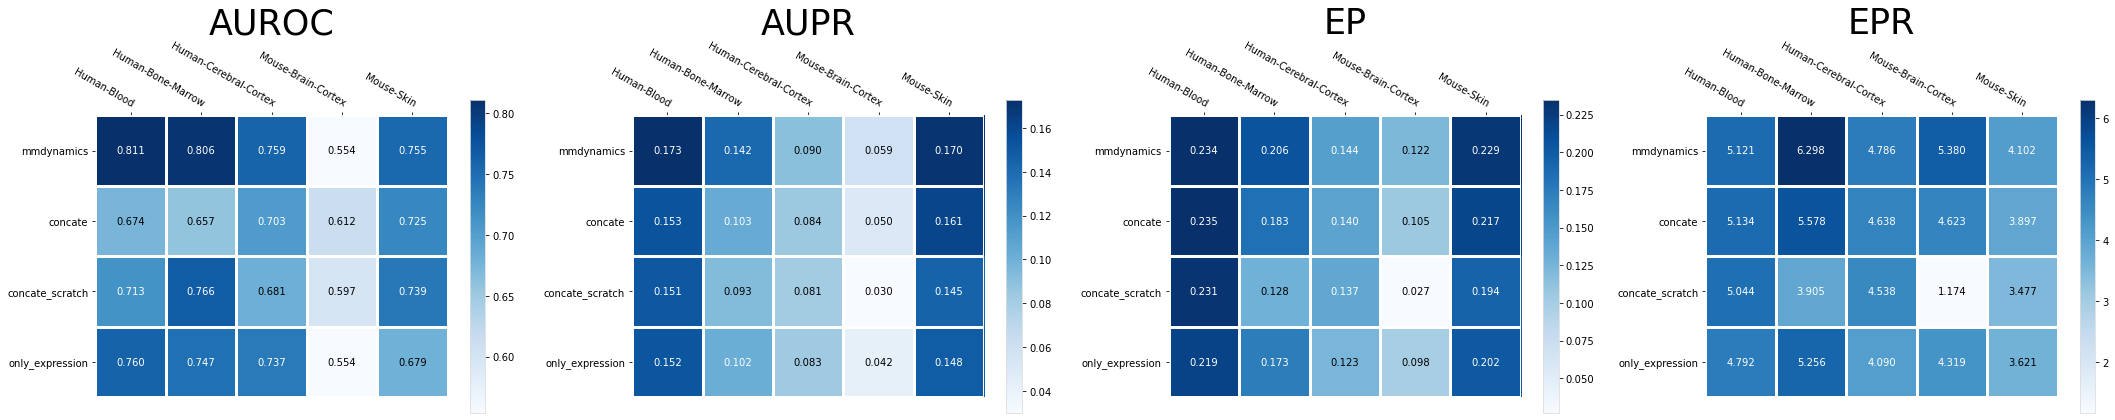

In [104]:
# Plot two heatmap of the dataframe that contains df_auroc and df_aupr by matplotlib
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(30, 6))
# set the font size
plt.rcParams.update({'font.size': 10})
# set the font family
plt.rcParams["font.family"] = "sans-serif"
# set padding of title
# plt.suptitle('AUROC and AUPR of Specific Dataset', fontsize=40, y=0.95)
ax1.set_title('AUROC', fontsize=35)
im1, cbar1 = heatmap(df_auroc.values, df_auroc.index, df_auroc.columns, ax=ax1, cmap="Blues", cbarlabel="") # cmap="YlGn"
texts1 = annotate_heatmap(im1, valfmt="{x:.3f}")
ax2.set_title('AUPR', fontsize=35)
im2, cbar2 = heatmap(df_aupr.values, df_aupr.index, df_aupr.columns, ax=ax2, cmap="Blues", cbarlabel="")
texts2 = annotate_heatmap(im2, valfmt="{x:.3f}")
ax3.set_title('EP', fontsize=35)
im3, cbar3 = heatmap(df_ep.values, df_ep.index, df_ep.columns, ax=ax3, cmap="Blues", cbarlabel="")
texts3 = annotate_heatmap(im3, valfmt="{x:.3f}")
ax4.set_title('EPR', fontsize=35)
im4, cbar4 = heatmap(df_epr.values, df_epr.index, df_epr.columns, ax=ax4, cmap="Blues", cbarlabel="")
texts4 = annotate_heatmap(im4, valfmt="{x:.3f}")
# plt.show()
plt.tight_layout()
plt.subplots_adjust(top=0.75)

plt.savefig('./_figure/model_ablation_study/deepmix_model_ablation_study_heatmap.pdf', dpi=600)
plt.savefig('./_figure/model_ablation_study/deepmix_model_ablation_study_heatmap.jpg', dpi=100)

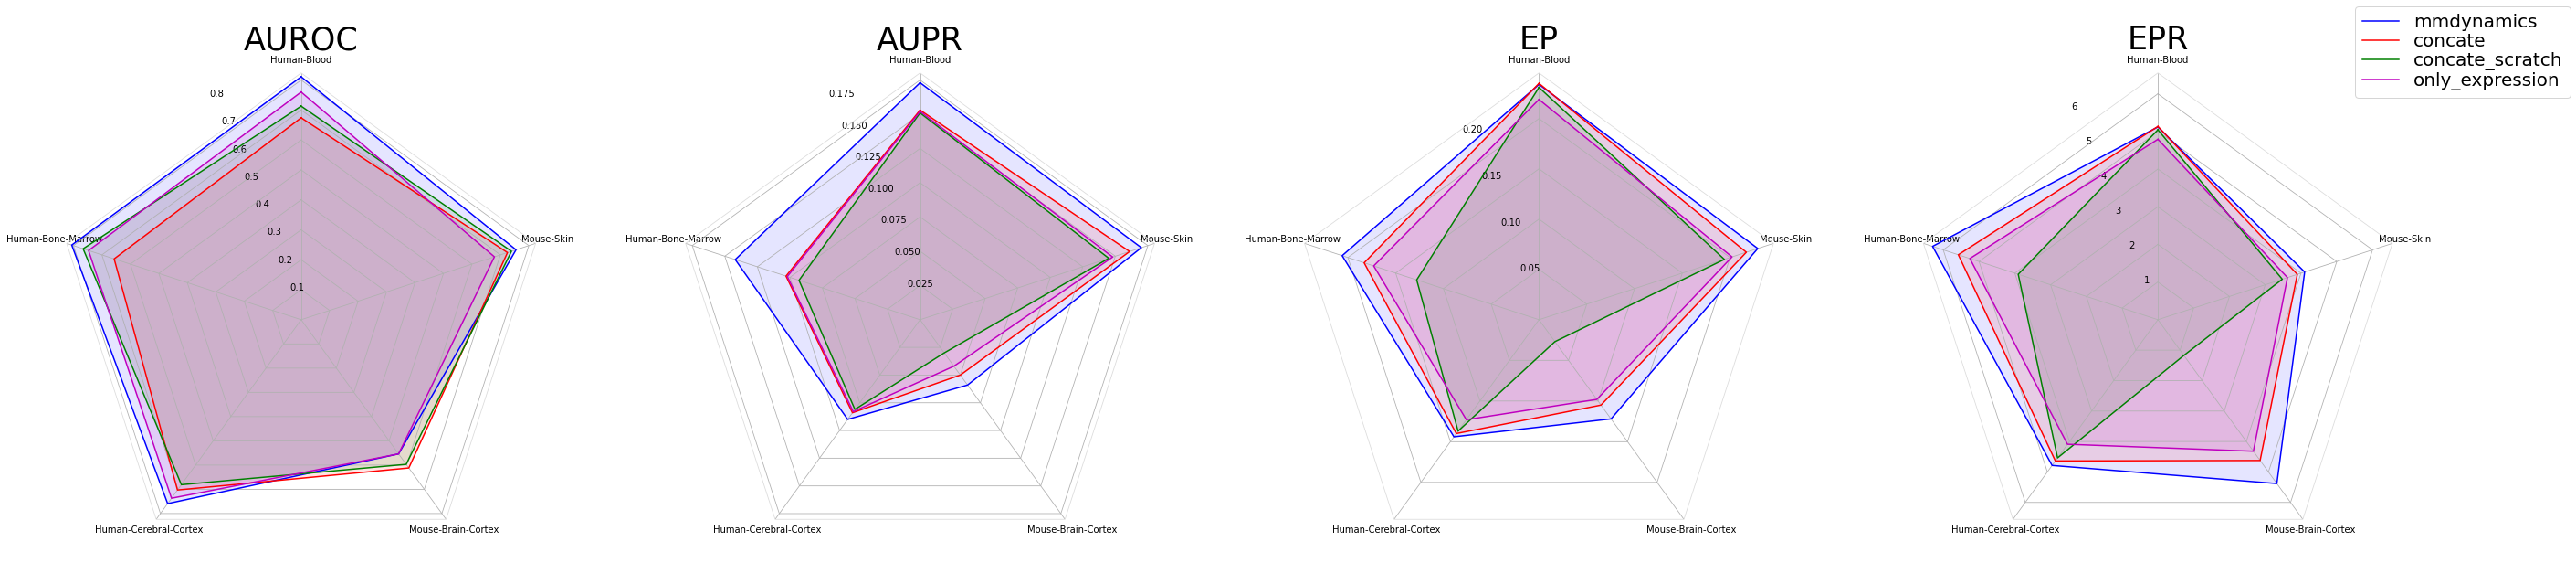

In [28]:
fig, axs = plt.subplots(figsize=(40, 9), nrows=1, ncols=4, subplot_kw=dict(projection='radar'))
fig.subplots_adjust(wspace=0.25, hspace=0.20, top=0.85, bottom=0.05)

data = [['Human-Blood', 'Human-Bone-Marrow', 'Human-Cerebral-Cortex', 'Mouse-Brain-Cortex', 'Mouse-Skin'],
        ('AUROC', df_auroc.values), ('AUPR', df_aupr.values), ('EP', df_ep.values), ('EPR', df_epr.values)]
spoke_labels = data.pop(0)

theta = radar_factory(5, frame='polygon')
colors = ['b', 'r', 'g', 'm']

plt.rcParams.update({'font.size': 10})
# Plot the four cases from the example data on separate axes
for ax, (title, case_data) in zip(axs.flat, data):
    ax.set_title(title, weight='normal', position=(0.5, 1.1), horizontalalignment='center', verticalalignment='center', fontsize=35)
    for d, color in zip(case_data, colors):
        ax.plot(theta, d, color=color)
        ax.fill(theta, d, facecolor=color, alpha=0.1, label='_nolegend_')
    ax.set_varlabels(spoke_labels) # set the font size    

# add legend relative to top-left plot
labels = ('mmdynamics', 'concate', 'concate_scratch', 'only_expression')
legend = axs[3].legend(labels, loc=(0.9, .95), labelspacing=0.1, fontsize=20)
plt.tight_layout()
plt.subplots_adjust(top=0.85)

plt.savefig('./_figure/model_ablation_study/deepmix_model_ablation_study_radar.pdf', dpi=600)
plt.savefig('./_figure/model_ablation_study/deepmix_model_ablation_study_radar.jpg', dpi=100)


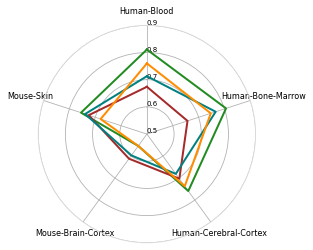

In [50]:
# Reference: https://www.python-graph-gallery.com/391-radar-chart-with-several-individuals
df = pd.DataFrame({
    'group': ['A', 'B', 'C', 'D'],
    'Human-Blood': [0.811, 0.674, 0.713, 0.760],
    'Human-Bone-Marrow': [0.806, 0.657, 0.766, 0.747],
    'Human-Cerebral-Cortex': [0.759, 0.703, 0.681, 0.737],
    'Mouse-Brain-Cortex': [0.554, 0.612, 0.597, 0.554],
    'Mouse-Skin': [0.755, 0.725, 0.739, 0.679]
}) # AUROC

palette = plt.get_cmap('Set1')

# Create background
categories = ['Human-Blood', 'Human-Bone-Marrow', 'Human-Cerebral-Cortex', 'Mouse-Brain-Cortex', 'Mouse-Skin']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

ax = plt.subplot(111, polar=True)
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, color='black', size=8)
ax.set_rlabel_position(0)
plt.yticks([0.50, 0.60, 0.70, 0.80, 0.90], ["0.5", "0.6", "0.7", "0.8",'0.9'], color="black", size=7)
plt.ylim(0.5, 0.9)

values = df.loc[0].drop('group').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, color='forestgreen', linewidth=2, linestyle='solid', label="mmdynamics")
# ax.fill(angles, values, 'b', alpha=0.2)
values = df.loc[1].drop('group').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, color='brown', linewidth=2, linestyle='solid', label="concate")
# ax.fill(angles, values, 'r', alpha=0.2)
values = df.loc[2].drop('group').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, color='teal', linewidth=2, linestyle='solid', label="concate_scratch")
# ax.fill(angles, values, 'grey', alpha=0.2)
values = df.loc[3].drop('group').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, color='darkorange', linewidth=2, linestyle='solid', label="only_expression")
# ax.fill(angles, values, 'blue', alpha=0.2)
# plt.legend(loc='upper right', bbox_to_anchor=(0.2, 0.1))

# Show the graph
plt.savefig("./_figure/model_ablation_study/deepmix_model_ablation_study_radar_2.pdf", dpi=600)
plt.savefig("./_figure/model_ablation_study/deepmix_model_ablation_study_radar_2.jpg", dpi=100)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


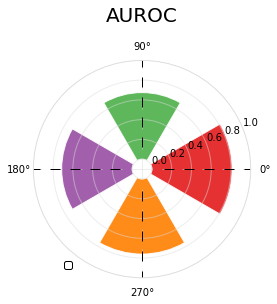

In [107]:
import matplotlib
import numpy as np
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'group': ['A', 'B', 'C', 'D'],
    'Human-Blood': [0.811, 0.674, 0.713, 0.760],
    'Human-Bone-Marrow': [0.806, 0.657, 0.766, 0.747],
    'Human-Cerebral-Cortex': [0.759, 0.703, 0.681, 0.737],
    'Mouse-Brain-Cortex': [0.554, 0.612, 0.597, 0.554],
    'Mouse-Skin': [0.755, 0.725, 0.739, 0.679]
}) # AUROC

matplotlib.rc('axes', edgecolor='gainsboro')
result = df['Human-Blood'].values  

N = 4
theta = np.linspace(0.0, 2 * np.pi, N, endpoint=False)
width = np.pi / 3
cmap = plt.get_cmap("Set1")
colors = [cmap(0), cmap(2), cmap(3), cmap(4), cmap(5), cmap(6), cmap(7)]
ax = plt.subplot(projection='polar')
plt.grid(axis='y', color='gainsboro', linestyle='-', linewidth=1, alpha=0.5) 
plt.grid(axis='x', color='gainsboro', linestyle='--', linewidth=1, dashes=(10,10), alpha=0.5)


ax.set_rlim(-0.1, 1.0)
ax.set_rorigin(-0.1)
for i in theta:
    ax.axvline(i, 0.2, 1.0, linestyle='--', linewidth=1, color='black', dashes=(10,10))

bar = ax.bar(x=theta, height=result, width=width, bottom=0, color=colors, alpha=0.9, edgecolor='w')
ax.set_xticks(np.arange(0, 360, 360 / N) / 180 * np.pi)
# ax.set_xticklabels(['A', 'B', 'C', 'D'], fontsize=15, color='black', rotation=0)
# ax.set_xticklabels(['mmdynamics', 'concate', 'concate_scratch', 'only_expression'], fontsize=15, color='black', rotation=0)
# ax.legend(['mmdynamics', 'concate', 'concate_scratch', 'only_expression'], loc='upper right', bbox_to_anchor=(0.2, 0.1))
ax.legend(loc='upper right', bbox_to_anchor=(0.2, 0.1), frameon=True, facecolor='white', edgecolor='black', framealpha=1)
ax.set_facecolor('white')
ax.tick_params(axis='both', color='white')
# plt.legend(bar, ['mmdynamics', 'concate', 'concate_scratch', 'only_expression'], loc='upper right', bbox_to_anchor=(0.2, 0.1), frameon=True, facecolor='white', edgecolor='black', framealpha=1)
plt.title('AUROC', fontsize=20, pad=20)
plt.savefig('./_figure/model_ablation_study/bar_{}.jpg'.format('AUROC'), bbox_inches='tight', dpi=800)
plt.savefig('./_figure/model_ablation_study/bar_{}.pdf'.format('AUROC'), bbox_inches='tight', dpi=800)